# A. Table of content:

- [B. Instructions:](#B-Instructions:)    
- [C. Import, functions & data load:](#C.-Import,-functions-&-data-load:)    
- [1. Data pre-processing:](#1.-Data-pre-processing:)  
    - [1.1. Dataset inspection:](#1.1.-Dataset-inspection:)   
    - [1.2. Feature engineering:](#1.2.-Feature-engineering:)  
        - [1.2.1. General:](#1.2.1.-General:)  
        - [1.2.2. Preparation for machine learning modeling:](#1.2.2.-Preparation-for-machine-learning-modeling:)  
        - [1.2.3. Preparation for deep learning modeling:](#1.2.3.-Preparation-for-deep-learning-modeling:)   
        - [1.2.4. Preparation for transformer modeling:](#1.2.4.-Preparation-for-transformer-modeling:)    
- [2. Modeling:](#2.-Modeling:)  
    - [2.1. Machine learning modeling - Random Forest:](#2.1.-Machine-learning-modeling---Random-Forest:)  
        - [2.1.1. Bayesian optimization:](#2.1.1.-Bayesian-optimization:)  
        - [2.1.2. Random Forest modeling:](#2.1.2.-Random-Forest-modeling:)
    - [2.2. Machine learning modeling - Logistic Regression:](#2.2.-Machine-learning-modeling---Logistic-Regression:)  
        - [2.2.1. Bayesian optimization:](#2.2.1.-Bayesian-optimization:)  
        - [2.2.2. Logistic Regression modeling:](#2.2.2.-Logistic-Regression-modeling:)  
    - [2.3. Deep learning modeling:](#2.3.-Deep-learning-modeling:)   
    - [2.4. Transformer modeling:](#2.4.-Transformer-modeling:)
    - [2.5. Performance metrics, model selection & overall conclusion:](#2.5.-Performance-metrics,-model-selection-&-overall-conclusion:)
        - [2.5.1. Machine learning modeling - Random Forest performance metrics:](#2.5.1.-Machine-learning-modeling---Random-Forest-performance-metrics:)
        - [2.5.2. Machine learning modeling - Logistic Regression performance metrics:](#2.5.2.-Machine-learning-modeling---Logistic-Regression-performance-metrics:)
        - [2.5.3. Deep learning performance metrics:](#2.5.3.-Deep-learning-performance-metrics:)
        - [2.5.4. Transformer performance metrics:](#2.5.4.-Transformer-performance-metrics:)
        - [2.5.5. Model selection:](#2.5.5.-Model-selection:)  

# IMPORTANT NOTE:

**In the first attemps of this Capstone Three, the Kaggle dataset failed to fill in the objectives.    
Indeed, the first provided dataset was clearly unable to support any classification due to the lack or signal.** 

**Therefore, a new dataset which has been checked and it will be used to be run again the following stages:  
    - Data wrangling.  
    - EDA.  
    - Preprocessing.  
    - Modeling.**  
    
**The Jupyter Notebooks to consider for this new dataset are:  
    - "CapstoneThree_DataWrangling_EDA.ipynb_Reliable_Ds.ipynb"  
    - "CapstoneThree_Preprocessing_Modeling_Reliable_Ds.ipynb"**

# B. Instructions:

In [1]:
from IPython.display import IFrame

In [2]:
instructions_path = r"..\references\4_5_PreProcessing_Modeling\1585013368_Capstone_Three_Steps_4-5_-_Google_Docs.pdf"

In [3]:
IFrame(instructions_path, width=800, height=600)

# C. Import, functions & data load:

**IMPORT:**

In [4]:
import pandas as pd
import spacy
# !python -m spacy download en_core_web_md
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_selection import f_classif
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.ensemble import RandomForestClassifier
from bayes_opt import BayesianOptimization
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score
# !pip install tensorflow
import tensorflow as tf
import keras
from keras.metrics import AUC
from keras import layers, models, regularizers
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, f1_score, roc_auc_score
# from keras.regularizers import l2
from sklearn.linear_model import LogisticRegression
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from scipy.special import softmax
import torch
# %pip install -q ipywidgets
import transformers
from transformers.utils.logging import set_verbosity_info


Note: you may need to restart the kernel to use updated packages.


**CONDA ENVIRONMENT EXPORT:**

In [90]:
# !conda env export -n nlpenv --no-builds > CapstoneThree_Preprocessing_Modeling_Reliable_Ds_envenv.yml
# !dir CapstoneThree_Preprocessing_Modeling_Reliable_Ds_env.yml

 Volume in drive C is OS
 Volume Serial Number is 3CC3-E130

 Directory of C:\Users\Benoit Loze\Desktop\SPRINGBOARD\_CURSUS\34_Deep_Learning\34.4_Capstone_Three\34.4_capstonethree_fakenewsdetection\notebooks



File Not Found


**FUNCTIONS**

In [6]:
# Text normatilzation function:
def clean_column(df, col):
    """
    Load a spaCy model, tokenize df[col], and write a cleaned text column f"{col}_cleaned".
    Removes punctuation, digits, stopwords; keeps tokens with at least one letter; lemmatizes & lowercases.
    """

    nlp = spacy.load("en_core_web_md")

    docs = list(nlp.pipe(df[col], batch_size=100, n_process=4))

    df[f"{col}_cleaned"] = [
        " ".join(
        token.lemma_.lower()
        for token in doc
        if not token.is_punct
        and not token.is_digit
        and not token.is_stop
        and any(c.isalpha() for c in token.text)
        )
        for doc in docs
    ]
    return df

In [7]:
def model_performance_metrics(model, research_method, y_test, y_pred):
    """
    Compute, print and return the F1, Precision, Recall scores
    Display the classification report and the confusion matrix
    """

    # compute metrics:
    f1_score_model = f1_score(y_test, y_pred, average="macro")
    precision_model = precision_score(y_test, y_pred, average="macro")
    recall_model = recall_score(y_test, y_pred, average="macro")
    classification_report_model = classification_report(y_test, y_pred)
    cm_model = confusion_matrix(y_test, y_pred)

    # print metrics:
    print(f"{model}, {research_method}, F1 score: {f1_score_model}.")
    print(f"{model}, {research_method}, Precision score: {precision_model}.")
    print(f"{model}, {research_method}, Recall score: {recall_model}.")
    print(f"\n{model}, {research_method}, Classification Report:\n {classification_report_model}.")
    print()

    #display confusion matrix:
    cm_model_display = ConfusionMatrixDisplay(confusion_matrix=cm_model)
    cm_model_display.plot(cmap="Blues")
    plt.title(f"{model} - {research_method}, Confusion Matrix")
    plt.show()

    # returns metrics for logging or comparison:
    return {"f1":f1_score_model, "precision":precision_model, "recall":recall_model}

**DATA LOAD:**

**Important note:**  
Before running the code, please ensure to unzip the **"WELFake_Dataset.zip"** to prepare for the correct .csv dataset file.  

In [8]:
dataset_path = r"..\data\raw\WELFake_Dataset.csv"

In [9]:
df = pd.read_csv(dataset_path)

# 1. Data wrangling:

## 1.1. Dataset inspection:

In [12]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [13]:
df.shape

(72134, 4)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


In [15]:
df.drop("Unnamed: 0", axis=1, inplace=True)

## 1.2. Missing values:

In [16]:
df["title"].isnull().sum()

558

In [17]:
df["text"].isnull().sum()

39

In [18]:
df = df.dropna(subset=["title", "text"])

In [19]:
df["label"].value_counts()

label
1    36509
0    35028
Name: count, dtype: int64

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71537 entries, 0 to 72133
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   71537 non-null  object
 1   text    71537 non-null  object
 2   label   71537 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.2+ MB


## 1.3. Duplicates:

In [21]:
title_dup = df["title"].duplicated().sum()
print(f"Duplicated tiles: {title_dup}.")

article_dup = df["text"].duplicated().sum()
print(f"Duplicated artices: {article_dup}.")

title_article_dup = df.duplicated(subset=["title", "text"]).sum()
print(f"Duplicate title & article pair: {title_article_dup}")

Duplicated tiles: 9229.
Duplicated artices: 9337.
Duplicate title & article pair: 8416


In [22]:
df = df.drop_duplicates(subset=["title"])
df = df.drop_duplicates(subset=["text"])
df = df.drop_duplicates(subset=["title", "text"])

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61393 entries, 0 to 72132
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   61393 non-null  object
 1   text    61393 non-null  object
 2   label   61393 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.9+ MB


In [24]:
df["label"].value_counts()

label
0    34237
1    27156
Name: count, dtype: int64

## 1.4. Class imbalance:

In [25]:
label_balance = df["label"].value_counts().reset_index()
label_balance.columns = ["label", "count"]
label_balance

,label,count
0,0,34237
1,1,27156


In [26]:
label_diff = abs(label_balance.loc[label_balance["label"]==0, "count"].values[0]-label_balance.loc[label_balance["label"]==1, "count"].values[0])
label_diff_percentage = round(((label_diff / df.shape[0]) * 100), 2)

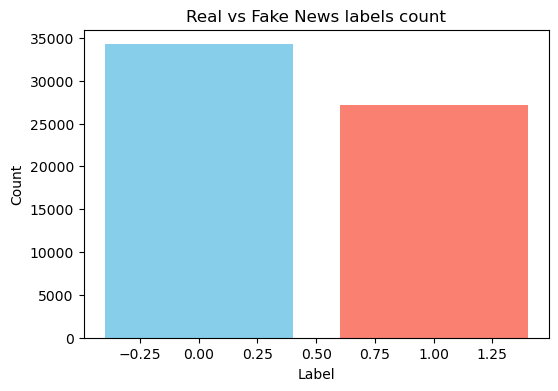

In [27]:
plt.figure(figsize=(6,4))
plt.bar(label_balance["label"], label_balance["count"], color=["skyblue", "salmon"])
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Real vs Fake News labels count")
plt.show()

**CONCLUSION:**

In [28]:
print(f"The difference between the labels 'real' and 'fake' is {label_diff}, which represents a minor percentage of {label_diff_percentage}%.")

The difference between the labels 'real' and 'fake' is 7081, which represents a minor percentage of 11.53%.


There is a slight **class imbalance** in the target label, favouring the **"fake news" type.**

## 1.5. Text normalization:

The **"clean_column"** function supports, at once:   
- the tokenization of a chosen feature column of the dataset.  
- the removal of punctuations, digits and stop words.  
- the selection of words with at least one alpha character.
- the final lemmatization and the character lowering.

In [29]:
clean_column(df, "title")

,title,text,label,title_cleaned
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,law enforcement high alert follow threat cop w...
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,unbelievable obama attorney general say charlo...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,bobby jindal raise hindu use story christian c...
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,satan russia unveli image terrifying new super...
5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,time christian group sue amazon splc designati...
...,...,...,...,...
72127,WIKILEAKS EMAIL SHOWS CLINTON FOUNDATION FUNDS...,An email released by WikiLeaks on Sunday appea...,1,wikileaks email shows clinton foundation fund ...
72129,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0,russians steal research trump hack u.s. democr...
72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1,watch giuliani demand democrats apologize trum...
72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0,migrant refuse leave train refugee camp hungary


In [30]:
clean_column(df, "text")

,title,text,label,title_cleaned,text_cleaned
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,law enforcement high alert follow threat cop w...,comment expect barack obama member fyf911 fuky...
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,unbelievable obama attorney general say charlo...,demonstrator gather night exercise constitutio...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,bobby jindal raise hindu use story christian c...,dozen politically active pastor come private d...
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,satan russia unveli image terrifying new super...,rs-28 sarmat missile dub satan replace ss-18 f...
5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,time christian group sue amazon splc designati...,s time sue southern poverty law center!on tues...
...,...,...,...,...,...
72127,WIKILEAKS EMAIL SHOWS CLINTON FOUNDATION FUNDS...,An email released by WikiLeaks on Sunday appea...,1,wikileaks email shows clinton foundation fund ...,email release wikileaks sunday appear aide bil...
72129,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0,russians steal research trump hack u.s. democr...,washington reuters hacker believe work russian...
72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1,watch giuliani demand democrats apologize trum...,know fantasyland republicans question citizens...
72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0,migrant refuse leave train refugee camp hungary,migrant refuse leave train refugee camp hungar...


In [31]:
df.head()

,title,text,label,title_cleaned,text_cleaned
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,law enforcement high alert follow threat cop w...,comment expect barack obama member fyf911 fuky...
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,unbelievable obama attorney general say charlo...,demonstrator gather night exercise constitutio...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,bobby jindal raise hindu use story christian c...,dozen politically active pastor come private d...
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,satan russia unveli image terrifying new super...,rs-28 sarmat missile dub satan replace ss-18 f...
5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,time christian group sue amazon splc designati...,s time sue southern poverty law center!on tues...


In [32]:
df["title_cleaned"].isnull().sum()

0

In [33]:
df["text_cleaned"].isnull().sum()

0

## 1.5. Save:

The initial "title" and "text" columns will be saved (df_raw).
For safety their content will be saved as a .csv file for any futher retrieval (transfomer processing).

In [34]:
df_raw = df[["title", "text"]]
raw = r"..\data\processed\_correct_dataset\df_raw.csv"
df_raw.to_csv(raw, index=False, encoding="utf-8")

In [35]:
df_X = df[["title_cleaned", "text_cleaned"]]
X_path = r"..\data\processed\_correct_dataset\df_X.csv"
df_raw.to_csv(X_path, index=False, encoding="utf-8")

In [36]:
df_y = df["label"]
y_path = r"..\data\processed\_correct_dataset\df_y.csv"
df_raw.to_csv(y_path, index=False, encoding="utf-8")

In [37]:
df_y.head()

0    1
2    1
3    0
4    1
5    1
Name: label, dtype: int64

# 2. Data pre-processing:

## 1.2. Feature engineering:

### 1.2.2. Preparation for machine learning modeling:

**Train/test split** is taking place **before** the TF-IDF vectorization **to avoid any "data leakage"**.  
**"title_cleaned"** and **"text_cleaned"** features are **vectorized separately**.  
This will allow the ML model **to exploit the signals** from both features **independently** for better efficiency.  

In [38]:
df_y = df_y.squeeze()

X_train_df, X_test_df, y_train, y_test = train_test_split(
    df_X,
    df_y,
    test_size=0.2,
    random_state=42,
    stratify=df_y
)

In [39]:
y_train = getattr(y_train, "values", y_train)
y_test  = getattr(y_test, "values", y_test)
y_train = y_train.ravel()
y_test  = y_test.ravel()

# print(y_train)
# print(y_test)

In [40]:
tfidf_title = TfidfVectorizer(max_features=2000, ngram_range=(1, 2))
X_title_train = tfidf_title.fit_transform(X_train_df["title_cleaned"])
X_title_test = tfidf_title.transform(X_test_df["title_cleaned"])

In [41]:
tfidf_text = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_text_train = tfidf_text.fit_transform(X_train_df["text_cleaned"])
X_text_test = tfidf_text.transform(X_test_df["text_cleaned"])

In [42]:
# combine into one sparse matrix:
X_train = hstack([X_title_train, X_text_train]).tocsr()
X_test = hstack([X_title_test, X_text_test]).tocsr()

### 1.2.3. Preparation for deep learning modeling:

In [43]:
# Tokenizer expect a Series, "title_cleaned" and "text_cleaned" are combined to preserve signals from both features:
df_X["combined"] = df_X["title_cleaned"].str.strip() + " / " + df_X["text_cleaned"].str.strip()

C:\Users\Benoit Loze\AppData\Local\Temp\ipykernel_20224\2769862103.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_X["combined"] = df_X["title_cleaned"].str.strip() + " / " + df_X["text_cleaned"].str.strip()


In [44]:
df_X.head()

,title_cleaned,text_cleaned,combined
0,law enforcement high alert follow threat cop w...,comment expect barack obama member fyf911 fuky...,law enforcement high alert follow threat cop w...
2,unbelievable obama attorney general say charlo...,demonstrator gather night exercise constitutio...,unbelievable obama attorney general say charlo...
3,bobby jindal raise hindu use story christian c...,dozen politically active pastor come private d...,bobby jindal raise hindu use story christian c...
4,satan russia unveli image terrifying new super...,rs-28 sarmat missile dub satan replace ss-18 f...,satan russia unveli image terrifying new super...
5,time christian group sue amazon splc designati...,s time sue southern poverty law center!on tues...,time christian group sue amazon splc designati...


In [45]:
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    df_X["combined"],
    df_y, test_size = 0.2,
    random_state=42,
    stratify=df_y
)

In [46]:
y_train_dl = np.asarray(y_train_dl).ravel()
y_test_dl = np.asarray(y_test_dl).ravel()

### 1.2.4. Preparation for transformer modeling:

In [47]:
df_raw.head()

,title,text
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ..."
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will..."
5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...


In [48]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61393 entries, 0 to 72132
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   61393 non-null  object
 1   text    61393 non-null  object
dtypes: object(2)
memory usage: 1.4+ MB


In [49]:
df_raw["title"] = df_raw["title"].str.lower()
df_raw["text"] = df_raw["text"].str.lower()

C:\Users\Benoit Loze\AppData\Local\Temp\ipykernel_20224\1753122383.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_raw["title"] = df_raw["title"].str.lower()
C:\Users\Benoit Loze\AppData\Local\Temp\ipykernel_20224\1753122383.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_raw["text"] = df_raw["text"].str.lower()


In [50]:
df_raw["text_all"] = (df_raw["title"] + " / " + df_raw["text"])

C:\Users\Benoit Loze\AppData\Local\Temp\ipykernel_20224\2899544390.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_raw["text_all"] = (df_raw["title"] + " / " + df_raw["text"])


In [51]:
df_raw.head()

,title,text,text_all
0,law enforcement on high alert following threat...,no comment is expected from barack obama membe...,law enforcement on high alert following threat...
2,unbelievable! obama’s attorney general says mo...,"now, most of the demonstrators gathered last ...",unbelievable! obama’s attorney general says mo...
3,"bobby jindal, raised hindu, uses story of chri...",a dozen politically active pastors came here f...,"bobby jindal, raised hindu, uses story of chri..."
4,satan 2: russia unvelis an image of its terrif...,"the rs-28 sarmat missile, dubbed satan 2, will...",satan 2: russia unvelis an image of its terrif...
5,about time! christian group sues amazon and sp...,all we can say on this one is it s about time ...,about time! christian group sues amazon and sp...


In [52]:
y = df_y.to_numpy().astype("int64", copy=False)

X_train_tr, X_test_tr, y_train_tr, y_test_tr = train_test_split(
    df_raw["text_all"], df_y.values,
    test_size=0.2, random_state=42, stratify=y
)

In [53]:
model_name = "distilbert-base-uncased" # roberta-base / deberta-v3-base / electra-small-discriminator
MAX_LEN = 512
tok = AutoTokenizer.from_pretrained(model_name) 

C:\Users\Anaconda\envs\nlpenv\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [54]:
def encode(texts):
    enc = tok(list(texts), truncation=True, padding=True, max_length=MAX_LEN, return_tensors="np")
    return {k: enc[k] for k in ["input_ids", "attention_mask"]}

train_enc = encode(X_train_tr)
test_enc  = encode(X_test_tr)

train_data = {**train_enc, "labels": np.array(y_train_tr, dtype=np.int64)}
test_data  = {**test_enc,  "labels": np.array(y_test_tr,  dtype=np.int64)}

class NumpyDataset:
    def __init__(self, d): self.d = d
    def __len__(self): return len(self.d["labels"])
    def __getitem__(self, i): return {k: v[i] for k, v in self.d.items()}

train_ds = NumpyDataset(train_data)
valid_ds = NumpyDataset(test_data)

# 2. Modeling:

## 2.1. Machine learning modeling - Random Forest:

### 2.1.1. Bayesian optimization:

In [55]:
CRITERIONS = ["gini", "entropy"]
MAX_FEATURES = ["sqrt", "log2"]
BOOTSTRAP = [True, False]

**STEP 1 - FUNCTION:**

In [56]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def rf_optimization(
    n_estimators, max_depth, min_samples_split,min_samples_leaf, 
    criterion_val, max_features_val, bootstrap_val
):
    """
    Accept hyperparameters:
        - n_estimators
        - criterion
        - max_depth
        - min_samples_split
        - min_samples_leaf
        - max_features
        - bootstrap
        - class_weight
    Trains a RandomForest model.
    Evaluates it with cross validation.
    Returns a F1_macro score.
    """

    # use of int() to avoid unexpected error if optimizer tries float values.
    rf_model = RandomForestClassifier(
        n_estimators=int(n_estimators),
        max_depth=int(max_depth),
        min_samples_split=int(min_samples_split),
        min_samples_leaf=int(min_samples_leaf),
        bootstrap=BOOTSTRAP[int(bootstrap_val)],
        criterion=CRITERIONS[int(criterion_val)],                 
        max_features=MAX_FEATURES[int(max_features_val)],
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        estimator=rf_model, 
        X=X_train, 
        y=y_train, 
        scoring="f1_macro", 
        cv=3,  
        verbose=2)
    
    return scores.mean()

**STEP 2 - OPTIMIZER:**

In [57]:
bounds_tree = {
    "n_estimators":(100, 700),
    "max_depth":(10, 200),
    "min_samples_split":(2, 20),
    "min_samples_leaf":(1,10),
    "bootstrap_val":(0, 1),
    "criterion_val":(0, 1),
    "max_features_val":(0, 1),
}

optimizer_tree = BayesianOptimization(
    f=rf_optimization,
    pbounds=bounds_tree,
    random_state=42,
    verbose=2
) 

In [58]:
optimizer_tree.maximize(init_points=5, n_iter=15)

|   iter    |  target   | bootst... | criter... | max_depth | max_fe... | min_sa... | min_sa... | n_esti... |
-------------------------------------------------------------------------------------------------------------
[CV] END .................................................... total time=   8.3s
[CV] END .................................................... total time=   8.8s
[CV] END .................................................... total time=   8.7s
| 1         | 0.9521    | 0.3745    | 0.9507    | 149.1     | 0.5987    | 2.404     | 4.808     | 134.9     |


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:   26.1s finished


[CV] END .................................................... total time=   8.9s
[CV] END .................................................... total time=   8.9s
[CV] END .................................................... total time=   9.3s
| 2         | 0.9444    | 0.8662    | 0.6011    | 144.5     | 0.02058   | 9.729     | 16.98     | 227.4     |


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:   27.3s finished


[CV] END .................................................... total time=  25.5s
[CV] END .................................................... total time=  34.3s
[CV] END .................................................... total time=  25.3s
| 3         | 0.9503    | 0.1818    | 0.1834    | 67.81     | 0.5248    | 4.888     | 7.242     | 467.1     |


...

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:   53.3s finished


[CV] END .................................................... total time=  12.0s
[CV] END .................................................... total time=  12.3s
[CV] END .................................................... total time=  12.5s
| 19        | 0.9533    | 0.3191    | 0.3404    | 144.3     | 0.0798    | 1.363     | 2.068     | 154.3     |


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:   37.2s finished


[CV] END .................................................... total time=  40.3s
[CV] END .................................................... total time=  39.9s
[CV] END .................................................... total time=  41.0s
| 20        | 0.9521    | 0.8945    | 0.4253    | 105.2     | 0.3012    | 2.181     | 19.25     | 666.3     |


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:  2.0min finished


**STEP 3 - BEST PARAMETERS:**

In [59]:
best_params_tree = optimizer_tree.max["params"]
print(best_params_tree)

{'bootstrap_val': 0.6940427677403537, 'criterion_val': 0.36209424928230194, 'max_depth': 122.37543851968115, 'max_features_val': 0.8033971429329204, 'min_samples_leaf': 1.7230892584472277, 'min_samples_split': 16.718529743887633, 'n_estimators': 673.6636487772938}


### 2.1.2. Random Forest modeling:

In [60]:
bootstrap=BOOTSTRAP[int(round(best_params_tree["bootstrap_val"]))]
criterion= CRITERIONS[int(round(best_params_tree["criterion_val"]))]
max_features= MAX_FEATURES[int(round(best_params_tree["max_features_val"]))]

In [61]:
# best RandomForest model based on best parameters for performance petrics:
best_rf_model = RandomForestClassifier(
    n_estimators=int(round(best_params_tree["n_estimators"])),
    max_depth=int(round(best_params_tree["max_depth"])),
    min_samples_split=int(round(best_params_tree["min_samples_split"])),
    min_samples_leaf=int(round(best_params_tree["min_samples_leaf"])),
    bootstrap=bootstrap,
    criterion=criterion,               
    max_features=max_features,
    random_state=42,
    n_jobs=-1
)

In [62]:
best_rf_model.fit(X_train, y_train)
y_pred_rf = best_rf_model.predict(X_test)

## 2.2. Machine learning modeling - Logistic Regression:

### 2.2.1. Bayesian optimization:

**STEP 1 - FUNCTION:**

Due to the use of TF-IDF, there is **no need to standardize** the data (StandardScaler).

In [63]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def lr_optimization(C_log):
    C = float(10 ** C_log)
  
    lr_model = LogisticRegression(
        C=C,
        penalty="l2",
        solver="lbfgs",
         max_iter=2000,
        random_state=42
    )
    scores = cross_val_score(
        estimator=lr_model,
        X=X_train,
        y=y_train,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1
    )
    return scores.mean()

**STEP 2 - OPTIMIZER:**

In [64]:
bounds_lr = {
    "C_log": (-3, 3),
}

optimizer_lr = BayesianOptimization(
    f=lr_optimization,
    pbounds=bounds_lr,
    random_state=42,
    verbose=2
) 

In [65]:
optimizer_lr.maximize(init_points=5, n_iter=15)

|   iter    |  target   |   C_log   |
-------------------------------------
| 1         | 0.9473    | -0.7528   |
| 2         | 0.9593    | 2.704     |
| 3         | 0.9613    | 1.392     |
| 4         | 0.9624    | 0.592     |
| 5         | 0.8985    | -2.064    |
| 6         | 0.96      | 2.078     |
| 7         | 0.9588    | 0.02175   |
| 8         | 0.9625    | 0.9539    |
| 9         | 0.9592    | 3.0       |
| 10        | 0.9626    | 0.7795    |
| 11        | 0.9628    | 0.8342    |
| 12        | 0.9605    | 1.72      |
| 13        | 0.9613    | 0.3616    |
| 14        | 0.9631    | 0.8662    |
| 15        | 0.4664    | -3.0      |
| 16        | 0.9289    | -1.461    |
| 17        | 0.9541    | -0.3784   |
| 18        | 0.9596    | 2.39      |
| 19        | 0.9617    | 1.203     |
| 20        | 0.9603    | 1.896     |


**STEP 3 - BEST PARAMETERS:**

In [66]:
best_params_lr = optimizer_lr.max["params"]
print(best_params_lr)

{'C_log': 0.8662143796530829}


### 2.2.2. Logistic Regression modeling:

In [67]:
best_C = float(10 ** best_params_lr["C_log"])

best_lr_model = LogisticRegression(
    C=best_C,
    penalty="l2",
    solver="lbfgs",
    max_iter=2000,
    random_state=42
)

In [68]:
best_lr_model.fit(X_train, y_train)
y_pred_lr = best_lr_model.predict(X_test)

## 2.3. Deep learning modeling:

**TEXT VECTORIZATION:**

In [69]:
VOCAB_SIZE = 30000
MAXLEN     = 300

vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAXLEN,
    standardize=None,   # text already cleaned by spaCy
    split="whitespace"  
)
# adapt only on training text to avoid leakage:
vectorizer.adapt(X_train_dl)

**MODELING:**

In [70]:
EMB_DIM = 100

model_dl = models.Sequential([
    layers.Input(shape=(), dtype=tf.string, name="text"),
    vectorizer,
    layers.Embedding(VOCAB_SIZE, EMB_DIM, mask_zero=True,
                     embeddings_regularizer=regularizers.l2(1e-6)),
    layers.SpatialDropout1D(0.3),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.3)),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.3)),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid"),
])

In [71]:
model_dl.compile(
    loss="binary_crossentropy",
    optimizer= Adam(learning_rate=1e-3),
    metrics=["accuracy", AUC(name="auc")]
)

In [87]:
# early stopping:
early_stop = EarlyStopping(
    monitor='val_loss',   # metric to monitor
    patience=4,           # stop after 4 epochs with no improvement
    restore_best_weights=True # roll back to the best model
)

In [88]:
history = model_dl.fit(
    X_train_dl, y_train_dl,
    validation_data=(X_test_dl, y_test_dl),
    epochs=20,
    batch_size=64,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/20
768/768 [==============================] - 538s 698ms/step - loss: 0.0090 - accuracy: 0.9989 - auc: 0.9999 - val_loss: 0.1044 - val_accuracy: 0.9792 - val_auc: 0.9929
Epoch 2/20
768/768 [==============================] - 531s 692ms/step - loss: 0.0076 - accuracy: 0.9992 - auc: 1.0000 - val_loss: 0.1219 - val_accuracy: 0.9774 - val_auc: 0.9917
Epoch 3/20
768/768 [==============================] - 593s 772ms/step - loss: 0.0068 - accuracy: 0.9994 - auc: 1.0000 - val_loss: 0.1176 - val_accuracy: 0.9803 - val_auc: 0.9917


## 2.4. Transformer modeling:

In [74]:
# import os, shutil, subprocess, textwrap, sys
# print("Python:", sys.version)
# print("Conda env:", os.environ.get("CONDA_DEFAULT_ENV"))
# print("nvidia-smi in PATH:", shutil.which("nvidia-smi"))
# if shutil.which("nvidia-smi"):
#     print(subprocess.run(["nvidia-smi"], text=True, capture_output=True).stdout)

In [75]:
# # %pip install --quiet --upgrade pip
# %pip uninstall -y torch torchvision torchaudio -q
# %pip install --index-url https://download.pytorch.org/whl/cu121 \
# "torch==2.4.1" "torchvision==0.19.1" "torchaudio==2.4.1"

In [76]:
# import torch
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.4.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU


In [77]:
set_verbosity_info()

In [78]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)


def compute_metrics(p):
    logits, labels = p.predictions, p.label_ids  # Trainer gives numpy arrays
    preds  = logits.argmax(axis=-1)
    probs1 = softmax(logits, axis=-1)[:, 1]
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1":       f1_score(labels, preds),
        "auc":      roc_auc_score(labels, probs1),
    }


args = TrainingArguments(
    output_dir="./out",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=6,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="auc",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    seed=42,

    #GPU:
    fp16=True,                 
    tf32=True,                 
    dataloader_pin_memory=False,
    dataloader_num_workers=0   
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,   # NumpyDataset
    eval_dataset=valid_ds,    # NumpyDataset
    tokenizer=tok,
    compute_metrics=compute_metrics
)

print("CUDA available before training:", torch.cuda.is_available())
trainer.train()

loading configuration file config.json from cache at C:\Users\Benoit Loze\.cache\huggingface\hub\models--distilbert-base-uncased\snapshots\12040accade4e8a0f71eabdb258fecc2e7e948be\config.json
Model config DistilBertConfig {
  "_name_or_path": "distilbert-base-uncased",
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "dim": 768,
  "dropout": 0.1,
  "hidden_dim": 3072,
  "initializer_range": 0.02,
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "transformers_version": "4.44.2",
  "vocab_size": 30522
}

loading weights file model.safetensors from cache at C:\Users\Benoit Loze\.cache\huggingface\hub\models--distilbert-base-uncased\snapshots\12040accade4e8a0f71eabdb258fecc2e7e948be\model.safetensors
Some weights of the model checkpoint at distilbert-base

CUDA available before training: True


***** Running training *****
  Num examples = 49,114
  Num Epochs = 6
  Instantaneous batch size per device = 16
  Total train batch size (w. parallel, distributed & accumulation) = 16
  Gradient Accumulation steps = 1
  Total optimization steps = 18,420
  Number of trainable parameters = 66,955,010


Epoch,Training Loss,Validation Loss,Accuracy,F1,Auc
1,0.031400,0.084814,0.980780,0.977795,0.999590
2,0.016500,0.041353,0.990797,0.989517,0.999745
3,0.009800,0.025809,0.994381,0.993639,0.999797
4,0.000100,0.034275,0.994788,0.994113,0.999864
5,0.000000,0.043130,0.994136,0.993355,0.999863
6,0.000000,0.043920,0.994544,0.993822,0.999851



***** Running Evaluation *****
  Num examples = 12279
  Batch size = 32
Saving model checkpoint to ./out\checkpoint-3070
Configuration saved in ./out\checkpoint-3070\config.json
Model weights saved in ./out\checkpoint-3070\model.safetensors
tokenizer config file saved in ./out\checkpoint-3070\tokenizer_config.json
Special tokens file saved in ./out\checkpoint-3070\special_tokens_map.json

***** Running Evaluation *****
  Num examples = 12279
  Batch size = 32
Saving model checkpoint to ./out\checkpoint-6140
Configuration saved in ./out\checkpoint-6140\config.json
Model weights saved in ./out\checkpoint-6140\model.safetensors
tokenizer config file saved in ./out\checkpoint-6140\tokenizer_config.json
Special tokens file saved in ./out\checkpoint-6140\special_tokens_map.json

***** Running Evaluation *****
  Num examples = 12279
  Batch size = 32
Saving model checkpoint to ./out\checkpoint-9210
Configuration saved in ./out\checkpoint-9210\config.json
Model weights saved in ./out\checkpoi

TrainOutput(global_step=18420, training_loss=0.012705063779153914, metrics={'train_runtime': 4011.2129, 'train_samples_per_second': 73.465, 'train_steps_per_second': 4.592, 'total_flos': 3.90360229055447e+16, 'train_loss': 0.012705063779153914, 'epoch': 6.0})

## 2.5. Performance metrics, model selection & overall conclusion:

### 2.5.1. Machine learning modeling - Random Forest performance metrics:

**METRICS:**

random forest, bayesian optimization, F1 score: 0.9223405563913727.
random forest, bayesian optimization, Precision score: 0.9258255382754087.
random forest, bayesian optimization, Recall score: 0.9199970568534391.

random forest, bayesian optimization, Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93      6848
           1       0.94      0.89      0.91      5431

    accuracy                           0.92     12279
   macro avg       0.93      0.92      0.92     12279
weighted avg       0.92      0.92      0.92     12279
.



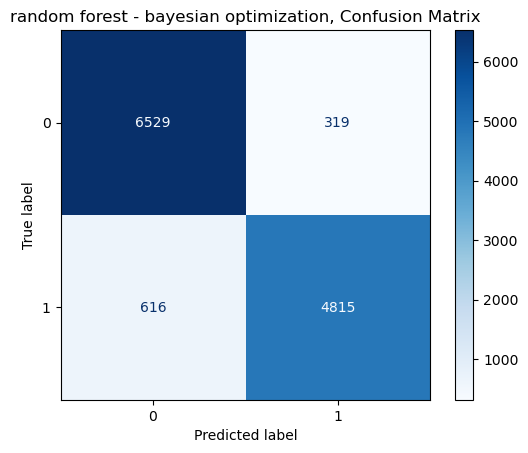

{'f1': 0.9223405563913727, 'precision': 0.9258255382754087, 'recall': 0.9199970568534391}


In [79]:
rf_bopt_metrics = model_performance_metrics("random forest", "bayesian optimization", y_test, y_pred_rf)
print(rf_bopt_metrics)

**CONCLUSION:**

The results are **strong and well balanced** among precision, recall and F1 scores.  
The model seems to miss a little bit more class 1 ("real") classification.  
**F1 score = 92%** 

### 2.5.2. Machine learning modeling - Logistic Regression performance metrics:

**METRICS:**

logistic regression, bayesian optimization, F1 score: 0.9581661695030101.
logistic regression, bayesian optimization, Precision score: 0.9580215259922213.
logistic regression, bayesian optimization, Recall score: 0.9583146283364623.

logistic regression, bayesian optimization, Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96      6848
           1       0.95      0.95      0.95      5431

    accuracy                           0.96     12279
   macro avg       0.96      0.96      0.96     12279
weighted avg       0.96      0.96      0.96     12279
.



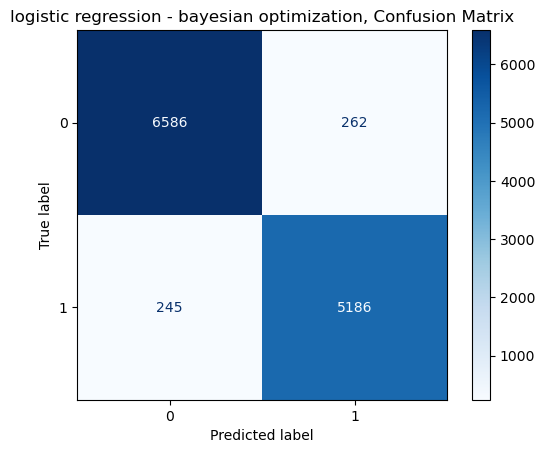

In [80]:
lr_bopt_metrics = model_performance_metrics("logistic regression", "bayesian optimization", y_test, y_pred_lr)

**CONCLUSION:**

**Very strong** and **very balanced results** among among precision, recall and F1 scores.  
The errors are **low and symmetric** with no class favouring.   
**F1 score = 96%**  

### 2.5.3. Deep learning performance metrics:

**METRICS:**

In [81]:
y_prob = model_dl.predict(X_test_dl, batch_size=256)
y_pred_dl = (y_prob >= 0.5).astype(int).ravel()
print(classification_report(y_test_dl, y_pred_dl, digits=3))
print("F1-macro:", f1_score(y_test_dl, y_pred_dl, average="macro"))
print("ROC-AUC:", roc_auc_score(y_test_dl, y_prob))

48/48 [==============================] - 124s 3s/step
              precision    recall  f1-score   support

           0      0.964     0.991     0.977      6848
           1      0.988     0.953     0.970      5431

    accuracy                          0.974     12279
   macro avg      0.976     0.972     0.973     12279
weighted avg      0.974     0.974     0.974     12279

F1-macro: 0.9734827962919322
ROC-AUC: 0.9976330874419437


In [82]:
print(history.history.keys())

dict_keys(['loss', 'accuracy', 'auc', 'val_loss', 'val_accuracy', 'val_auc'])


In [83]:
hist = history.history
epochs = range(1, len(hist["loss"]) + 1)

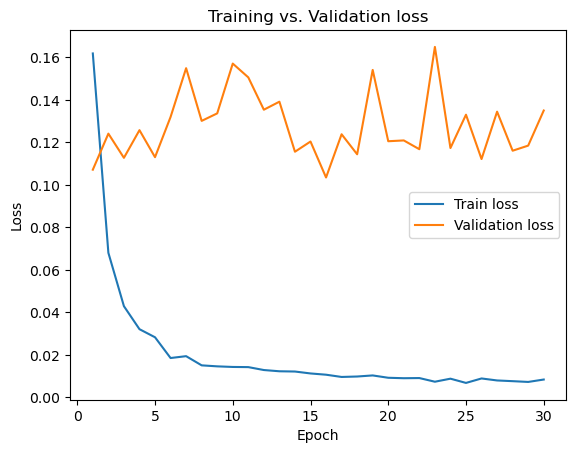

In [84]:
# train and validation loss:
plt.figure()
plt.plot(epochs, hist["loss"], label="Train loss")
plt.plot(epochs, hist["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs. Validation loss")
plt.legend()
plt.show()

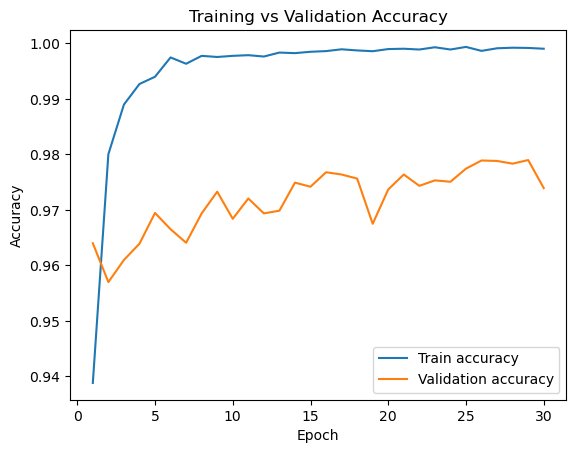

In [85]:
# train and validation accuracy:
plt.figure()
plt.plot(epochs, hist["accuracy"], label="Train accuracy")
plt.plot(epochs, hist["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

**CONCLUSION:**

**Best results** so far among accuracy, F1 and ROC-AUC.  
Overall the **classes are balanced**.  
The curves show a **moderate overfitting** after 10 epoch, which justifies the implemenation of **"early stopping"**.  
**F1 score = 97.4%**    

### 2.5.4. Transformer performance metrics:

**METRICS:**

In [86]:
# prints eval_loss + metrics from compute_metrics
print(trainer.evaluate())

pred = trainer.predict(valid_ds)
logits = pred.predictions
probs1 = softmax(logits, axis=-1)[:, 1]
preds  = logits.argmax(axis=-1)

print("AUC:", roc_auc_score(y_test_tr, probs1))
print("F1 :", f1_score(y_test_tr, preds))
print("ACC:", accuracy_score(y_test_tr, preds))
print(classification_report(y_test_tr, preds, digits=3))


***** Running Evaluation *****
  Num examples = 12279
  Batch size = 32



***** Running Prediction *****
  Num examples = 12279
  Batch size = 32


{'eval_loss': 0.034275349229574203, 'eval_accuracy': 0.9947878491733855, 'eval_f1': 0.9941133186166299, 'eval_auc': 0.9998637725922663, 'eval_runtime': 42.8735, 'eval_samples_per_second': 286.401, 'eval_steps_per_second': 8.957, 'epoch': 6.0}
AUC: 0.9998637725922663
F1 : 0.9941133186166299
ACC: 0.9947878491733855
              precision    recall  f1-score   support

           0      0.996     0.995     0.995      6848
           1      0.993     0.995     0.994      5431

    accuracy                          0.995     12279
   macro avg      0.995     0.995     0.995     12279
weighted avg      0.995     0.995     0.995     12279



**CONCLUSION:**

**Best final results** and balanced among accuracy, F1 and ROC-AUC.   
**Minimal and symmetric errors** among classes.   
**F1 score = 99.5%**    

### 2.5.5. Model selection:

#### The transformer (DistilBERT) model is the slected model.  